In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

print("BIKE SHARING DEMAND PREDICTION: FEATURE ENGINEERING")


BIKE SHARING DEMAND PREDICTION: FEATURE ENGINEERING


In [22]:
# STEP 1: DATA LOADING AND INITIAL INSPECTION

print("STEP 1: DATA LOADING")


df_raw = pd.read_csv('hour_mycopy.csv')

print(f"\n✓ Dataset loaded: {df_raw.shape[0]} records, {df_raw.shape[1]} columns")
print(f"✓ Date range: {df_raw['dteday'].min()} to {df_raw['dteday'].max()}")

print("\nRaw data sample:")
print(df_raw.head(10))

print("\n Column data types:")
print(df_raw.dtypes)

print("\nTarget variable (cnt) statistics:")
print(df_raw['cnt'].describe())

print("\n  Checking for missing values:")
print(df_raw.isnull().sum())

STEP 1: DATA LOADING

✓ Dataset loaded: 17379 records, 17 columns
✓ Date range: 2011-01-01 to 2012-12-31

Raw data sample:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   
5        6  2011-01-01       1   0     1   5        0        6           0   
6        7  2011-01-01       1   0     1   6        0        6           0   
7        8  2011-01-01       1   0     1   7        0        6           0   
8        9  2011-01-01       1   0     1   8        0        6           0   
9       10  2011-01-01       1   0     1   9        0        6           0   

   weathersit  tem

In [28]:
# STEP 2: DATE PARSING AND TEMPORAL FEATURES
print("STEP 2: DATE PARSING AND TEMPORAL FEATURE EXTRACTION")

# Create working copy
df = df_raw.copy()

# Parse datetime
df['datetime'] = pd.to_datetime(df['dteday'])

# Extract temporal components for EDA and aggregation
df['day_of_week'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['datetime'].dt.day
df['week_of_year'] = df['datetime'].dt.isocalendar().week
df['day_of_year'] = df['datetime'].dt.dayofyear

print("\n✓ Datetime parsed and temporal features extracted")
print("\n📊 Temporal features sample:")
print(df[['datetime', 'yr', 'mnth', 'hr', 'weekday', 'day_of_week']].head(10))
print(df[['datetime', 'yr', 'mnth', 'hr', 'weekday', 'day_of_week']].tail(10))

STEP 2: DATE PARSING AND TEMPORAL FEATURE EXTRACTION

✓ Datetime parsed and temporal features extracted

📊 Temporal features sample:
    datetime  yr  mnth  hr  weekday  day_of_week
0 2011-01-01   0     1   0        6            5
1 2011-01-01   0     1   1        6            5
2 2011-01-01   0     1   2        6            5
3 2011-01-01   0     1   3        6            5
4 2011-01-01   0     1   4        6            5
5 2011-01-01   0     1   5        6            5
6 2011-01-01   0     1   6        6            5
7 2011-01-01   0     1   7        6            5
8 2011-01-01   0     1   8        6            5
9 2011-01-01   0     1   9        6            5
        datetime  yr  mnth  hr  weekday  day_of_week
17369 2012-12-31   1    12  14        1            0
17370 2012-12-31   1    12  15        1            0
17371 2012-12-31   1    12  16        1            0
17372 2012-12-31   1    12  17        1            0
17373 2012-12-31   1    12  18        1            0
17374 2012

In [ ]:
# STEP 3: DENORMALIZATION TO INTERPRETABLE UNITS
print("STEP 3: DENORMALIZING WEATHER VARIABLES")
print("Rationale: Convert normalized [0,1] values to actual physical units")
print("           for interpretability and meaningful feature engineering.")

# Denormalize 
df['temp_actual'] = df['temp'] * 41.0  # Max temp = 41°C
df['atemp_actual'] = df['atemp'] * 50.0  # Max apparent temp = 50°C
df['humidity_actual'] = df['hum'] * 100.0  # Max humidity = 100%
df['windspeed_actual'] = df['windspeed'] * 67.0  # Max windspeed = 67 km/h

print("\n✓ Weather variables denormalized to actual units")
print("\nDenormalized values sample:")
print(df[['temp', 'temp_actual', 'atemp', 'atemp_actual', 
          'hum', 'humidity_actual', 'windspeed', 'windspeed_actual']].head(10))

print("\n Denormalized statistics:")
print(df[['temp_actual', 'atemp_actual', 'humidity_actual', 'windspeed_actual']].describe())

STEP 3: DENORMALIZING WEATHER VARIABLES
Rationale: Convert normalized [0,1] values to actual physical units
           for interpretability and meaningful feature engineering.

✓ Weather variables denormalized to actual units

Denormalized values sample:
   temp  temp_actual   atemp  atemp_actual   hum  humidity_actual  windspeed  \
0  0.24         9.84  0.2879        14.395  0.81             81.0     0.0000   
1  0.22         9.02  0.2727        13.635  0.80             80.0     0.0000   
2  0.22         9.02  0.2727        13.635  0.80             80.0     0.0000   
3  0.24         9.84  0.2879        14.395  0.75             75.0     0.0000   
4  0.24         9.84  0.2879        14.395  0.75             75.0     0.0000   
5  0.24         9.84  0.2576        12.880  0.75             75.0     0.0896   
6  0.22         9.02  0.2727        13.635  0.80             80.0     0.0000   
7  0.20         8.20  0.2576        12.880  0.86             86.0     0.0000   
8  0.24         9.84  0.2

In [31]:
# STEP 4: COMPOSITE WEATHER FEATURES
print("STEP 4: CREATING COMPOSITE WEATHER FEATURES")
print("Rationale: Combine multiple weather factors into domain-informed indices")
print("           that capture biking comfort and conditions holistically.")

# Weather Comfort Index
# Weighted combination of favorable biking conditions
# Weights determined by domain knowledge of biking behavior
df['weather_comfort_index'] = (
    (df['temp_actual'] / 41.0) * 0.40 +          # Warmer is better (to a point)
    (1 - df['humidity_actual'] / 100.0) * 0.30 + # Lower humidity is better
    (1 - df['windspeed_actual'] / 67.0) * 0.20 + # Lower wind is better
    (1 - (df['weathersit'] - 1) / 3.0) * 0.10    # Clear weather is better
)

# Apparent temperature difference
# Captures wind chill and heat index effects
df['temp_feel_diff'] = df['atemp_actual'] - df['temp_actual']

print("\n✓ Composite weather features created:")
print("  • weather_comfort_index: Weighted comfort score [0,1]")
print("  • temp_feel_diff: Difference between apparent and actual temperature")

print("\n📊 Composite features sample:")
print(df[['temp_actual', 'humidity_actual', 'windspeed_actual', 
          'weathersit', 'weather_comfort_index', 'temp_feel_diff']].head(10))

STEP 4: CREATING COMPOSITE WEATHER FEATURES
Rationale: Combine multiple weather factors into domain-informed indices
           that capture biking comfort and conditions holistically.

✓ Composite weather features created:
  • weather_comfort_index: Weighted comfort score [0,1]
  • temp_feel_diff: Difference between apparent and actual temperature

📊 Composite features sample:
   temp_actual  humidity_actual  windspeed_actual  weathersit  \
0         9.84             81.0            0.0000           1   
1         9.02             80.0            0.0000           1   
2         9.02             80.0            0.0000           1   
3         9.84             75.0            0.0000           1   
4         9.84             75.0            0.0000           1   
5         9.84             75.0            6.0032           2   
6         9.02             80.0            0.0000           1   
7         8.20             86.0            0.0000           1   
8         9.84             75.0   

In [ ]:
# STEP 5: CYCLICAL TIME ENCODING
print("STEP 5: CYCLICAL ENCODING OF TEMPORAL FEATURES")
print("Rationale: Preserve circular nature of time (e.g., hour 23 is near hour 0)")
print("           using sine/cosine transformations.")

# Hour encoding (24-hour cycle)
df['hour_sin'] = np.sin(2 * np.pi * df['hr'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hr'] / 24.0)

# Month encoding (12-month cycle)
df['month_sin'] = np.sin(2 * np.pi * df['mnth'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['mnth'] / 12.0)

# Day of week encoding (7-day cycle)
df['day_sin'] = np.sin(2 * np.pi * df['weekday'] / 7.0)
df['day_cos'] = np.cos(2 * np.pi * df['weekday'] / 7.0)

print("\n✓ Cyclical encodings created for hour, month, and day of week")
print("\n Cyclical features sample (showing midnight and 11 PM to see continuity):")
print(df[df['hr'].isin([0, 1, 22, 23])][['hr', 'hour_sin', 'hour_cos']].head(8))

STEP 5: CYCLICAL ENCODING OF TEMPORAL FEATURES
Rationale: Preserve circular nature of time (e.g., hour 23 is near hour 0)
           using sine/cosine transformations.

✓ Cyclical encodings created for hour, month, and day of week

 Cyclical features sample (showing midnight and 11 PM to see continuity):
    hr  hour_sin  hour_cos
0    0  0.000000  1.000000
1    1  0.258819  0.965926
22  22 -0.500000  0.866025
23  23 -0.258819  0.965926
24   0  0.000000  1.000000
25   1  0.258819  0.965926
45  22 -0.500000  0.866025
46  23 -0.258819  0.965926


In [32]:
# STEP 6: CATEGORICAL TIME FEATURES
print("STEP 6: BINARY AND CATEGORICAL TIME INDICATORS")
print("Rationale: Capture distinct behavioral patterns during specific time periods.")

# Rush hour identification (commute times)
# Morning: 7-9 AM, Evening: 5-7 PM
df['is_rush_hour'] = ((df['hr'] >= 7) & (df['hr'] <= 9) | 
                      (df['hr'] >= 17) & (df['hr'] <= 19)).astype(int)

# Time of day categories
# Categories: 1=Morning (6-12), 2=Afternoon (12-18), 3=Evening (18-22), 4=Night (22-6)
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 1  # Morning
    elif 12 <= hour < 18:
        return 2  # Afternoon
    elif 18 <= hour < 22:
        return 3  # Evening
    else:
        return 4  # Night

df['time_category'] = df['hr'].apply(categorize_time_of_day)

print("\n✓ Categorical time features created:")
print("  • is_rush_hour: Binary indicator for commute peaks")
print("  • time_category: 4-level time-of-day categorization")

print("\n Rush hour distribution:")
print(df['is_rush_hour'].value_counts())

print("\n Time category sample:")
print(df[['hr', 'is_rush_hour', 'time_category']].head(24))

STEP 6: BINARY AND CATEGORICAL TIME INDICATORS
Rationale: Capture distinct behavioral patterns during specific time periods.

✓ Categorical time features created:
  • is_rush_hour: Binary indicator for commute peaks
  • time_category: 4-level time-of-day categorization

 Rush hour distribution:
is_rush_hour
0    13012
1     4367
Name: count, dtype: int64

 Time category sample:
    hr  is_rush_hour  time_category
0    0             0              4
1    1             0              4
2    2             0              4
3    3             0              4
4    4             0              4
5    5             0              4
6    6             0              1
7    7             1              1
8    8             1              1
9    9             1              1
10  10             0              1
11  11             0              1
12  12             0              2
13  13             0              2
14  14             0              2
15  15             0              2
16  16 

In [33]:
# STEP 7: LAG AND ROLLING WINDOW FEATURES
print("\n" + "="*80)
print("STEP 7: TEMPORAL LAG AND ROLLING WINDOW FEATURES")
print("="*80)
print("Rationale: Capture historical patterns and trends for time series prediction.")
print(" Note: First 168 rows will have NaN values for lag features (expected)")

# Sort by datetime to ensure proper lag calculation
df = df.sort_values(['datetime', 'hr']).reset_index(drop=True)

# Demand lag features
# Lag 24h: same hour yesterday
# Lag 168h: same hour last week
df['demand_lag_24h'] = df['cnt'].shift(24)
df['demand_lag_168h'] = df['cnt'].shift(168)

# Rolling averages for demand
# Captures short-term (24h) and medium-term (72h) trends
df['demand_rolling_24h'] = df['cnt'].shift(1).rolling(window=24, min_periods=1).mean()
df['demand_rolling_72h'] = df['cnt'].shift(1).rolling(window=72, min_periods=1).mean()

# Rolling weather averages (past 72 hours)
# Helps model understand recent weather trends
df['temp_rolling_72h'] = df['temp_actual'].rolling(window=72, min_periods=1).mean()
df['humidity_rolling_72h'] = df['humidity_actual'].rolling(window=72, min_periods=1).mean()
df['weather_comfort_rolling_72h'] = df['weather_comfort_index'].rolling(window=72, min_periods=1).mean()

print("\n✓ Lag and rolling features created:")
print("  • demand_lag_24h: Demand at same hour yesterday")
print("  • demand_lag_168h: Demand at same hour last week")
print("  • demand_rolling_24h: 24-hour rolling average (lag-shifted)")
print("  • demand_rolling_72h: 72-hour rolling average (lag-shifted)")
print("  • temp_rolling_72h: 72-hour rolling temperature average")
print("  • humidity_rolling_72h: 72-hour rolling humidity average")
print("  • weather_comfort_rolling_72h: 72-hour rolling comfort index")

print("\n Expected NaN values in first 168 rows (7 days):")
print(f"NaN count in demand_lag_168h: {df['demand_lag_168h'].isna().sum()}")

print("\n📊 Lag features sample (showing row 200+ to see actual values):")
print(df[['datetime', 'hr', 'cnt', 'demand_lag_24h', 'demand_lag_168h', 
          'demand_rolling_24h', 'demand_rolling_72h']].iloc[200:210])



STEP 7: TEMPORAL LAG AND ROLLING WINDOW FEATURES
Rationale: Capture historical patterns and trends for time series prediction.
 Note: First 168 rows will have NaN values for lag features (expected)

✓ Lag and rolling features created:
  • demand_lag_24h: Demand at same hour yesterday
  • demand_lag_168h: Demand at same hour last week
  • demand_rolling_24h: 24-hour rolling average (lag-shifted)
  • demand_rolling_72h: 72-hour rolling average (lag-shifted)
  • temp_rolling_72h: 72-hour rolling temperature average
  • humidity_rolling_72h: 72-hour rolling humidity average
  • weather_comfort_rolling_72h: 72-hour rolling comfort index

 Expected NaN values in first 168 rows (7 days):
NaN count in demand_lag_168h: 168

📊 Lag features sample (showing row 200+ to see actual values):
      datetime  hr  cnt  demand_lag_24h  demand_lag_168h  demand_rolling_24h  \
200 2011-01-09  15   82            74.0             20.0           35.125000   
201 2011-01-09  16   92            76.0            

In [34]:

# STEP 8: INTERACTION FEATURES
print("\n" + "="*80)
print("STEP 8: INTERACTION FEATURES")
print("="*80)
print("Rationale: Capture non-linear relationships between key predictors.")

# Working day × Rush hour interaction
# Captures commute behavior on working days specifically
df['workingday_rushhour'] = df['workingday'] * df['is_rush_hour']

# Season × Weather comfort interaction
# Different seasons have different comfort thresholds
df['season_comfort'] = df['season'] * df['weather_comfort_index']

# Temperature × Humidity interaction
# Combined effect on perceived comfort (heat index proxy)
df['temp_humidity_interact'] = (df['temp_actual'] * df['humidity_actual']) / 100.0

print("\n✓ Interaction features created:")
print("  • workingday_rushhour: Commute patterns on working days")
print("  • season_comfort: Seasonal weather comfort interaction")
print("  • temp_humidity_interact: Heat index proxy")

print("\nInteraction features sample:")
print(df[['workingday', 'is_rush_hour', 'workingday_rushhour', 
          'season', 'weather_comfort_index', 'season_comfort']].head(10))


STEP 8: INTERACTION FEATURES
Rationale: Capture non-linear relationships between key predictors.

✓ Interaction features created:
  • workingday_rushhour: Commute patterns on working days
  • season_comfort: Seasonal weather comfort interaction
  • temp_humidity_interact: Heat index proxy

Interaction features sample:
   workingday  is_rush_hour  workingday_rushhour  season  \
0           0             0                    0       1   
1           0             0                    0       1   
2           0             0                    0       1   
3           0             0                    0       1   
4           0             0                    0       1   
5           0             0                    0       1   
6           0             0                    0       1   
7           0             1                    0       1   
8           0             1                    0       1   
9           0             1                    0       1   

   weather_comfort

In [36]:
# STEP 9: FEATURE SELECTION - REMOVE REDUNDANT/LEAKING FEATURES
print("STEP 9: REMOVING REDUNDANT AND LEAKING FEATURES")
print("Rationale: Prevent target leakage and multicollinearity")

# Columns to drop with justification
drop_cols = {
    'instant': 'Record index (not predictive)',
    'dteday': 'Replaced by datetime',
    'temp': 'Redundant (using temp_actual)',
    'atemp': 'Redundant (using atemp_actual)',
    'hum': 'Redundant (using humidity_actual)',
    'windspeed': 'Redundant (using windspeed_actual)',
    'casual': ' TARGET LEAKAGE (cnt = casual + registered)',
    'registered': ' TARGET LEAKAGE (cnt = casual + registered)',
    'hr': 'Redundant (using cyclical encoding)',
    'mnth': 'Redundant (using cyclical encoding)',
    'weekday': 'Redundant (using cyclical encoding)',
}

print("\n📋 Columns to be dropped:")
for col, reason in drop_cols.items():
    print(f"  • {col}: {reason}")

df_model = df.drop(columns=list(drop_cols.keys()), errors='ignore')

print(f"\n✓ Dropped {len(drop_cols)} columns")
print(f"✓ Remaining columns: {df_model.shape[1]}")

STEP 9: REMOVING REDUNDANT AND LEAKING FEATURES
Rationale: Prevent target leakage and multicollinearity

📋 Columns to be dropped:
  • instant: Record index (not predictive)
  • dteday: Replaced by datetime
  • temp: Redundant (using temp_actual)
  • atemp: Redundant (using atemp_actual)
  • hum: Redundant (using humidity_actual)
  • windspeed: Redundant (using windspeed_actual)
  • casual:  TARGET LEAKAGE (cnt = casual + registered)
  • registered:  TARGET LEAKAGE (cnt = casual + registered)
  • hr: Redundant (using cyclical encoding)
  • mnth: Redundant (using cyclical encoding)
  • weekday: Redundant (using cyclical encoding)

✓ Dropped 11 columns
✓ Remaining columns: 29


In [13]:
# ============================================================================
# STEP 10: SEPARATE EDA VS MODELING FEATURES
# ============================================================================
print("\n" + "="*80)
print("STEP 10: DEFINING EDA vs MODELING FEATURES")
print("="*80)

# EDA features (for visualization and analysis only)
eda_features = ['datetime', 'day_of_week', 'day_of_month', 'week_of_year', 'day_of_year']

# Modeling features (for ML model training)
modeling_features = [col for col in df_model.columns 
                     if col not in eda_features + ['cnt']]

print("\n📊 EDA-only features (excluded from modeling):")
print(f"  {eda_features}")

print(f"\n🤖 Modeling features ({len(modeling_features)} total):")
for i, feat in enumerate(modeling_features, 1):
    print(f"  {i:2d}. {feat}")

print("\n🎯 Target variable: cnt")


STEP 10: DEFINING EDA vs MODELING FEATURES

📊 EDA-only features (excluded from modeling):
  ['datetime', 'day_of_week', 'day_of_month', 'week_of_year', 'day_of_year']

🤖 Modeling features (29 total):
   1. season
   2. yr
   3. holiday
   4. workingday
   5. weathersit
   6. temp_actual
   7. atemp_actual
   8. humidity_actual
   9. windspeed_actual
  10. weather_comfort_index
  11. temp_feel_diff
  12. hour_sin
  13. hour_cos
  14. month_sin
  15. month_cos
  16. day_sin
  17. day_cos
  18. is_rush_hour
  19. time_category
  20. demand_lag_24h
  21. demand_lag_168h
  22. demand_rolling_24h
  23. demand_rolling_72h
  24. temp_rolling_72h
  25. humidity_rolling_72h
  26. weather_comfort_rolling_72h
  27. workingday_rushhour
  28. season_comfort
  29. temp_humidity_interact

🎯 Target variable: cnt


In [ ]:

# STEP 11: FINAL DATASET OVERVIEW

print("\n" + "="*80)
print("STEP 11: FINAL TRANSFORMED DATASET")
print("="*80)

print(f"\n✓ Total records: {df_model.shape[0]:,}")
print(f"✓ Total features: {df_model.shape[1]}")
print(f"✓ Modeling features: {len(modeling_features)}")
print(f"✓ EDA features: {len(eda_features)}")
print(f"✓ Target variable: 1 (cnt)")

print("\n📊 Final dataset sample:")
print(df_model.head(20))

print("\n📊 Feature statistics:")
print(df_model[modeling_features].describe())

print("\n⚠️  Missing value check:")
missing_counts = df_model.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
if len(missing_counts) > 0:
    print(missing_counts)
else:
    print("✓ No missing values in final dataset")


STEP 11: FINAL TRANSFORMED DATASET

✓ Total records: 17,379
✓ Total features: 35
✓ Modeling features: 29
✓ EDA features: 5
✓ Target variable: 1 (cnt)

📊 Final dataset sample:
    season  yr  holiday  workingday  weathersit  cnt   datetime  day_of_week  \
0        1   0        0           0           1   16 2011-01-01            5   
1        1   0        0           0           1   40 2011-01-01            5   
2        1   0        0           0           1   32 2011-01-01            5   
3        1   0        0           0           1   13 2011-01-01            5   
4        1   0        0           0           1    1 2011-01-01            5   
5        1   0        0           0           2    1 2011-01-01            5   
6        1   0        0           0           1    2 2011-01-01            5   
7        1   0        0           0           1    3 2011-01-01            5   
8        1   0        0           0           1    8 2011-01-01            5   
9        1   0        0 

In [15]:
# ============================================================================
# STEP 12: YEAR-OVER-YEAR ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STEP 12: YEAR-OVER-YEAR GROWTH ANALYSIS")
print("="*80)

# Aggregate by year
year_0_demand = df_model[df_model['yr'] == 0]['cnt'].sum()
year_1_demand = df_model[df_model['yr'] == 1]['cnt'].sum()

year_0_avg = df_model[df_model['yr'] == 0]['cnt'].mean()
year_1_avg = df_model[df_model['yr'] == 1]['cnt'].mean()

growth_rate = ((year_1_demand - year_0_demand) / year_0_demand) * 100
avg_growth_rate = ((year_1_avg - year_0_avg) / year_0_avg) * 100

print(f"\n📊 Year 2011 (yr=0):")
print(f"  • Total demand: {year_0_demand:,}")
print(f"  • Average hourly demand: {year_0_avg:.2f}")

print(f"\n📊 Year 2012 (yr=1):")
print(f"  • Total demand: {year_1_demand:,}")
print(f"  • Average hourly demand: {year_1_avg:.2f}")

print(f"\n📈 Growth Metrics:")
print(f"  • Total growth rate: {growth_rate:.2f}%")
print(f"  • Average demand growth: {avg_growth_rate:.2f}%")

# Simple linear projection for Year 3
year_2_projected = year_1_demand * (1 + growth_rate/100)
print(f"\n🔮 Projected Year 2013 demand: {int(year_2_projected):,}")
print(f"   (Assuming {growth_rate:.2f}% growth continues)")


STEP 12: YEAR-OVER-YEAR GROWTH ANALYSIS

📊 Year 2011 (yr=0):
  • Total demand: 1,243,103
  • Average hourly demand: 143.79

📊 Year 2012 (yr=1):
  • Total demand: 2,049,576
  • Average hourly demand: 234.67

📈 Growth Metrics:
  • Total growth rate: 64.88%
  • Average demand growth: 63.20%

🔮 Projected Year 2013 demand: 3,379,254
   (Assuming 64.88% growth continues)


In [16]:
# ============================================================================
# STEP 13: CORRELATION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STEP 13: CORRELATION ANALYSIS")
print("="*80)

# Select key features for correlation analysis
key_features = ['cnt', 'temp_actual', 'humidity_actual', 'windspeed_actual',
                'weather_comfort_index', 'is_rush_hour', 'workingday', 
                'demand_lag_24h', 'demand_rolling_24h', 'season', 'yr']

corr_matrix = df_model[key_features].corr()

print("\n📊 Correlation with target variable (cnt):")
target_corr = corr_matrix['cnt'].sort_values(ascending=False)
print(target_corr)

print("\n⚠️  High correlation pairs (potential multicollinearity):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix.columns[i], 
                                   corr_matrix.columns[j], 
                                   corr_matrix.iloc[i, j]))

if high_corr_pairs:
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  • {feat1} ↔ {feat2}: {corr_val:.3f}")
else:
    print("  ✓ No highly correlated feature pairs found")


STEP 13: CORRELATION ANALYSIS

📊 Correlation with target variable (cnt):
cnt                      1.000000
demand_lag_24h           0.815765
weather_comfort_index    0.469600
is_rush_hour             0.453926
temp_actual              0.404772
demand_rolling_24h       0.401169
yr                       0.250495
season                   0.178056
windspeed_actual         0.093234
workingday               0.030284
humidity_actual         -0.322911
Name: cnt, dtype: float64

⚠️  High correlation pairs (potential multicollinearity):
  • cnt ↔ demand_lag_24h: 0.816



STEP 14: GENERATING VISUALIZATIONS


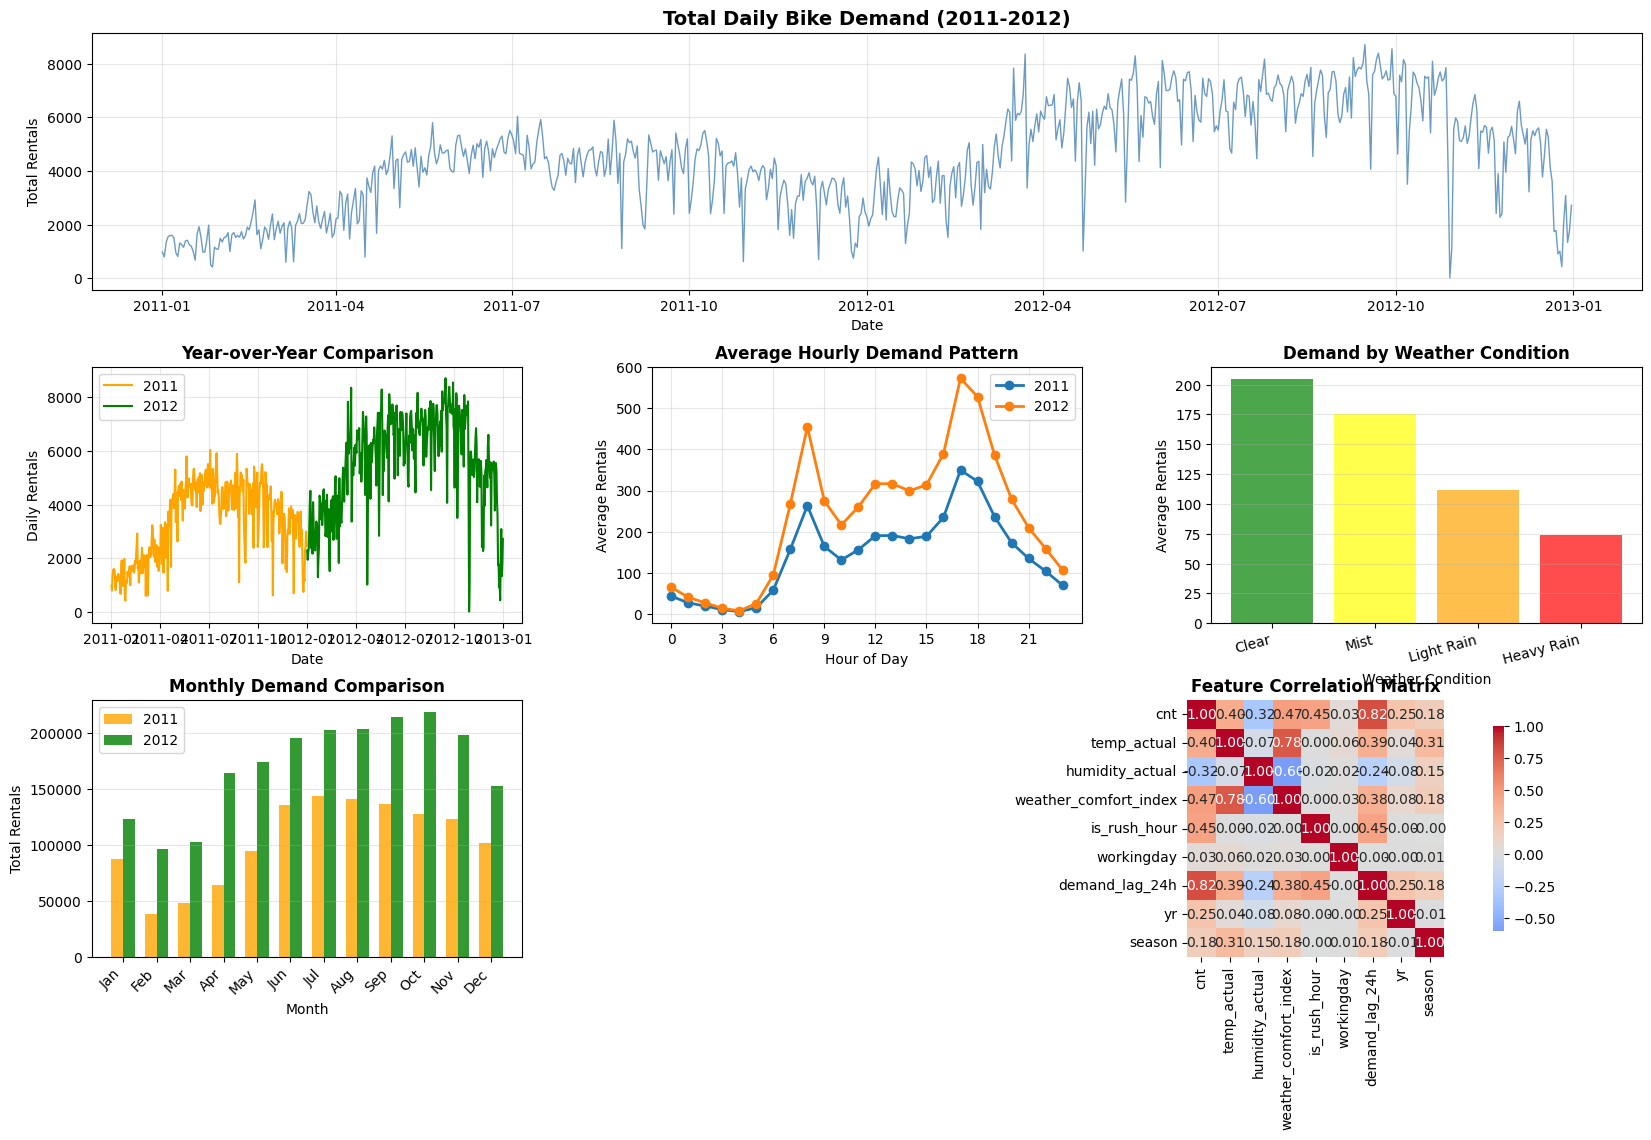


✓ Visualizations created and saved as 'bike_demand_analysis_refined.png'


In [17]:
# ============================================================================
# STEP 14: VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 14: GENERATING VISUALIZATIONS")
print("="*80)

# Prepare data for plotting
df_plot = df_model.copy()
df_plot['date'] = pd.to_datetime(df_plot['datetime']).dt.date

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Total demand over time
ax1 = fig.add_subplot(gs[0, :])
daily_demand = df_plot.groupby('date')['cnt'].sum()
ax1.plot(daily_demand.index, daily_demand.values, linewidth=1, color='steelblue', alpha=0.8)
ax1.set_title('Total Daily Bike Demand (2011-2012)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Rentals')
ax1.grid(True, alpha=0.3)

# 2. Year comparison
ax2 = fig.add_subplot(gs[1, 0])
year_0_daily = df_plot[df_plot['yr'] == 0].groupby('date')['cnt'].sum()
year_1_daily = df_plot[df_plot['yr'] == 1].groupby('date')['cnt'].sum()
ax2.plot(year_0_daily.index, year_0_daily.values, label='2011', linewidth=1.5, color='orange')
ax2.plot(year_1_daily.index, year_1_daily.values, label='2012', linewidth=1.5, color='green')
ax2.set_title('Year-over-Year Comparison', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Daily Rentals')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Hourly patterns by year
ax3 = fig.add_subplot(gs[1, 1])
hourly_avg = df_plot.groupby(['yr', 'hour_sin', 'hour_cos']).agg({'cnt': 'mean'}).reset_index()
# Reconstruct hour from sin/cos for plotting
hourly_avg['hour'] = np.arctan2(hourly_avg['hour_sin'], hourly_avg['hour_cos'])
hourly_avg['hour'] = ((hourly_avg['hour'] * 24 / (2 * np.pi)) + 24) % 24
hourly_avg = hourly_avg.sort_values('hour')

for year in [0, 1]:
    year_data = hourly_avg[hourly_avg['yr'] == year]
    ax3.plot(year_data['hour'], year_data['cnt'], 
            label=f'{2011 + year}', marker='o', linewidth=2)
ax3.set_title('Average Hourly Demand Pattern', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Average Rentals')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(0, 24, 3))

# 4. Weather impact
ax4 = fig.add_subplot(gs[1, 2])
weather_avg = df_plot.groupby('weathersit')['cnt'].mean()
weather_labels = ['Clear', 'Mist', 'Light Rain', 'Heavy Rain']
colors = ['green', 'yellow', 'orange', 'red']
ax4.bar(weather_avg.index, weather_avg.values, color=colors, alpha=0.7)
ax4.set_title('Demand by Weather Condition', fontsize=12, fontweight='bold')
ax4.set_xlabel('Weather Condition')
ax4.set_ylabel('Average Rentals')
ax4.set_xticks([1, 2, 3, 4])
ax4.set_xticklabels(weather_labels, rotation=15, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Monthly comparison
ax5 = fig.add_subplot(gs[2, 0])
monthly_demand = df_plot.groupby(['yr', 'month_sin', 'month_cos']).agg({'cnt': 'sum'}).reset_index()
# Reconstruct month from sin/cos
monthly_demand['month'] = np.arctan2(monthly_demand['month_sin'], monthly_demand['month_cos'])
monthly_demand['month'] = ((monthly_demand['month'] * 12 / (2 * np.pi)) + 12) % 12 + 1
monthly_demand = monthly_demand.sort_values('month')

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(12)
width = 0.35

year_0_monthly = monthly_demand[monthly_demand['yr'] == 0]['cnt'].values
year_1_monthly = monthly_demand[monthly_demand['yr'] == 1]['cnt'].values

ax5.bar(x - width/2, year_0_monthly, width, label='2011', color='orange', alpha=0.8)
ax5.bar(x + width/2, year_1_monthly, width, label='2012', color='green', alpha=0.8)
ax5.set_title('Monthly Demand Comparison', fontsize=12, fontweight='bold')
ax5.set_xlabel('Month')
ax5.set_ylabel('Total Rentals')
ax5.set_xticks(x)
ax5.set_xticklabels(months, rotation=45, ha='right')
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

# 6. Correlation heatmap
ax6 = fig.add_subplot(gs[2, 1:])
corr_features = ['cnt', 'temp_actual', 'humidity_actual', 'weather_comfort_index',
                'is_rush_hour', 'workingday', 'demand_lag_24h', 'yr', 'season']
corr_subset = df_model[corr_features].corr()
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           square=True, ax=ax6, cbar_kws={'shrink': 0.8})
ax6.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

plt.savefig('bike_demand_analysis_refined.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created and saved as 'bike_demand_analysis_refined.png'")

In [ ]:
# ============================================================================
# STEP 15: SAVE TRANSFORMED DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 15: EXPORTING TRANSFORMED DATASET")
print("="*80)

# Prepare final datasets
df_for_modeling = df_model[modeling_features + ['cnt']].copy()
df_with_eda = df_model.copy()

# Create CSV export and Excel file with multiple sheets
# Note: removed an invisible non-breaking space that caused a SyntaxError
df_for_modeling.to_csv('bike_sharing_transformed_refined.csv',index=False)

# Use a context manager to write multiple sheets safely
with pd.ExcelWriter('bike_sharing_transformed_refined.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Modeling dataset (clean, no EDA features)
    df_for_modeling.to_excel(writer, sheet_name='Modeling_Dataset', index=False)

    # Sheet 2: Full dataset (including EDA features)
    df_with_eda.to_excel(writer, sheet_name='Full_Dataset_with_EDA', index=False)

    # Sheet 3: Feature descriptions
    feature_desc = pd.DataFrame({
        'Feature': modeling_features + ['cnt'],
        'Type': ['Predictor'] * len(modeling_features) + ['Target'],
        'Description': [
            'Date and time of observation',
            'Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)',
            'Year (0=2011, 1=2012)',
            'Holiday indicator (1=Yes, 0=No)',
            'Working day indicator (1=Yes, 0=No)',
            'Weather situation (1=Clear, 2=Mist, 3=Light Rain, 4=Heavy)',
            'Temperature in Celsius (denormalized)',
            'Apparent temperature in Celsius (denormalized)',
            'Humidity percentage (denormalized)',
            'Wind speed in km/h (denormalized)',
            'Composite weather comfort index [0,1]',
            'Apparent temp minus actual temp (°C)',
            'Sine component of hour encoding',
            'Cosine component of hour encoding',
            'Sine component of month encoding',
            'Cosine component of month encoding',
            'Sine component of day-of-week encoding',
            'Cosine component of day-of-week encoding',
            'Rush hour indicator (7-9 AM, 5-7 PM)',
            'Time category (1=Morning, 2=Afternoon, 3=Evening, 4=Night)',
            'Demand 24 hours ago (same hour yesterday)',
            'Demand 168 hours ago (same hour last week)',
            '24-hour rolling average demand (lag-shifted)',
            '72-hour rolling average demand (lag-shifted)',
            '72-hour rolling average temperature',
            '72-hour rolling average humidity',
            '72-hour rolling average comfort index',
            'Working day × Rush hour interaction',
            'Season × Weather comfort interaction',
            'Temperature × Humidity interaction',
            'Total bike rentals (TARGET VARIABLE)'
        ][:len(modeling_features) + 1]
    })
    feature_desc.to_excel(writer, sheet_name='Feature_Descriptions', index=False)

    # Sheet 4: Year comparison summary
    year_comparison = pd.DataFrame({
        'Metric': ['Total Demand', 'Average Hourly Demand', 'Std Dev', 'Max Hourly Demand'],
        'Year_2011': [
            year_0_demand,
            year_0_avg,
            df_model[df_model['yr'] == 0]['cnt'].std(),
            df_model[df_model['yr'] == 0]['cnt'].max()
        ],
        'Year_2012': [
            year_1_demand,
            year_1_avg,
            df_model[df_model['yr'] == 1]['cnt'].std(),
            df_model[df_model['yr'] == 1]['cnt'].max()
        ],
        'Growth_%': [
            growth_rate,
            avg_growth_rate,
            ((df_model[df_model['yr'] == 1]['cnt'].std() - df_model[df_model['yr'] == 0]['cnt'].std()) / 
             df_model[df_model['yr'] == 0]['cnt'].std()) * 100,
            ((df_model[df_model['yr'] == 1]['cnt'].max() - df_model[df_model['yr'] == 0]['cnt'].max()) / 
             df_model[df_model['yr'] == 0]['cnt'].max()) * 100
        ]
    })
    year_comparison.to_excel(writer, sheet_name='Year_Comparison', index=False)

    # Sheet 5: Correlation analysis
    corr_analysis = corr_matrix['cnt'].sort_values(ascending=False).reset_index()
    corr_analysis.columns = ['Feature', 'Correlation_with_Target']
    corr_analysis.to_excel(writer, sheet_name='Correlation_Analysis', index=False)

print("\n✓ Excel file saved: 'bike_sharing_transformed_refined.xlsx'")
print("  📄 Sheet 1: Modeling_Dataset (ML-ready features)")



STEP 15: EXPORTING TRANSFORMED DATASET

✓ Excel file saved: 'bike_sharing_transformed_refined.xlsx'
  📄 Sheet 1: Modeling_Dataset (ML-ready features)
  📄 Sheet 2: Full_Dataset_with_EDA (includes temporal features)
  📄 Sheet 3: Feature_Descriptions (documentation)
  📄 Sheet 4: Year_Comparison (growth metrics)
  📄 Sheet 5: Correlation_Analysis (feature importance)


In [19]:
# ============================================================================
# STEP 16: FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 16: FINAL SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n🎯 FEATURE ENGINEERING SUMMARY:")
print("="*60)
print(f"✓ Total records processed: {df_model.shape[0]:,}")
print(f"✓ Original features: {df_raw.shape[1]}")
print(f"✓ Engineered features: {len(modeling_features)}")
print(f"✓ Features dropped (redundant/leaking): {len(drop_cols)}")

print("\n📊 FEATURE CATEGORIES:")
print("="*60)
print("  1. Temporal Features:")
print("     • Cyclical encodings (hour, month, day)")
print("     • Time categories (rush hour, time of day)")
print("  ")
print("  2. Weather Features:")
print("     • Denormalized actual values (temp, humidity, wind)")
print("     • Composite indices (weather comfort)")
print("     • Interaction terms (temp × humidity)")
print("  ")
print("  3. Historical Features:")
print("     • Lag features (24h, 168h)")
print("     • Rolling averages (24h, 72h)")
print("  ")
print("  4. Behavioral Features:")
print("     • Working day interactions")
print("     • Season-weather interactions")

print("\n🔍 KEY INSIGHTS:")
print("="*60)
print(f"  • Year-over-year growth: {growth_rate:.2f}%")
print(f"  • Average hourly demand increased: {avg_growth_rate:.2f}%")
print(f"  • Strongest correlations with demand:")

top_correlations = target_corr.drop('cnt').head(5)
for feat, corr_val in top_correlations.items():
    print(f"    - {feat}: {corr_val:.3f}")


print("\n📁 OUTPUT FILES:")
print("="*60)
print("  ✓ bike_sharing_transformed_refined.xlsx (5 sheets)")
print("  ✓ bike_demand_analysis_refined.png (visualizations)")

print("\n" + "="*80)
print("✅ FEATURE ENGINEERING PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)


STEP 16: FINAL SUMMARY AND RECOMMENDATIONS

🎯 FEATURE ENGINEERING SUMMARY:
✓ Total records processed: 17,379
✓ Original features: 17
✓ Engineered features: 29
✓ Features dropped (redundant/leaking): 11

📊 FEATURE CATEGORIES:
  1. Temporal Features:
     • Cyclical encodings (hour, month, day)
     • Time categories (rush hour, time of day)
  
  2. Weather Features:
     • Denormalized actual values (temp, humidity, wind)
     • Composite indices (weather comfort)
     • Interaction terms (temp × humidity)
  
  3. Historical Features:
     • Lag features (24h, 168h)
     • Rolling averages (24h, 72h)
  
  4. Behavioral Features:
     • Working day interactions
     • Season-weather interactions

🔍 KEY INSIGHTS:
  • Year-over-year growth: 64.88%
  • Average hourly demand increased: 63.20%
  • Strongest correlations with demand:
    - demand_lag_24h: 0.816
    - weather_comfort_index: 0.470
    - is_rush_hour: 0.454
    - temp_actual: 0.405
    - demand_rolling_24h: 0.401

📁 OUTPUT FILES

In [26]:

# OPTIONAL: Quick model-ready dataset preview

# Drop rows with NaN in lag features for clean modeling dataset
df_clean = df_for_modeling.dropna()

print(f"\n✓ Clean dataset (no missing values): {df_clean.shape[0]:,} rows")
print(f"✓ Rows dropped due to lag features: {df_for_modeling.shape[0] - df_clean.shape[0]}")

print("\n📊 Clean dataset sample (first 10 rows):")
print(df_clean.head(10))

print("\n📊 Clean dataset statistics:")
print(df_clean.describe())

print("\n🎯 Ready for modeling!")
print("   Target: 'cnt' (bike rental demand)")
print(f"   Features: {len(modeling_features)} predictors")
print(f"   Samples: {df_clean.shape[0]:,} observations")

# Save clean dataset separately
df_clean.to_excel('bike_sharing_model_ready.xlsx', index=False)
print("\n✓ Clean model-ready dataset saved: 'bike_sharing_model_ready.xlsx'")



✓ Clean dataset (no missing values): 17,211 rows
✓ Rows dropped due to lag features: 168

📊 Clean dataset sample (first 10 rows):
     season  yr  holiday  workingday  weathersit  temp_actual  atemp_actual  \
168       1   0        0           0           2         6.56         9.090   
169       1   0        0           0           3         6.56         9.090   
170       1   0        0           0           3         6.56         9.090   
171       1   0        0           0           2         7.38         9.850   
172       1   0        0           0           2         8.20         9.090   
173       1   0        0           0           2         8.20         9.090   
174       1   0        0           0           1         8.20         9.090   
175       1   0        0           0           1         8.20         8.335   
176       1   0        0           0           1         8.20         8.335   
177       1   0        0           0           1         7.38         6.820   
